# 🚢 Titanic Dataset — Full Exploratory Data Analysis

**Dataset:** Titanic passenger data (891 rows × 12 columns)  
**Source:** [Kaggle Titanic Competition](https://www.kaggle.com/c/titanic/data)  
**Goal:** Understand the structure of the data, distributions, missing values, correlations, and survival patterns — the full EDA workflow.

---
## Table of Contents
1. Setup & Data Loading
2. First Look — Shape, Dtypes, Head
3. Missing Value Analysis
4. Univariate Analysis (Distributions)
5. Bivariate Analysis (Survival vs Features)
6. Correlation Analysis
7. Feature Engineering Observations
8. Key Insights Summary

---
## 1. Setup & Data Loading

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Style settings
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.titlesize'] = 14
%matplotlib inline

print('Libraries loaded ✓')

Libraries loaded ✓


In [5]:
# Load dataset — downloading directly from a public mirror
url = 'https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv'
df = pd.read_csv(url)

print(f'Dataset loaded: {df.shape[0]} rows × {df.shape[1]} columns')

Dataset loaded: 891 rows × 12 columns


---
## 2. First Look — Shape, Dtypes, Head

Before doing anything else, always answer three questions:
- **What are the columns and their types?**
- **What does a single row look like?**
- **What's the basic statistical summary?**

In [6]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [8]:
# Descriptive statistics for numeric columns
df.describe().round(2)

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.00,891.00,891.00,714.00,891.00,891.00,891.00
mean,446.00,0.38,2.31,29.70,0.52,0.38,32.20
std,257.35,0.49,0.84,14.53,1.10,0.81,49.69
min,1.00,0.00,1.00,0.42,0.00,0.00,0.00
25%,223.50,0.00,2.00,20.12,0.00,0.00,7.91
50%,446.00,0.00,3.00,28.00,0.00,0.00,14.45
75%,668.50,1.00,3.00,38.00,1.00,0.00,31.00
max,891.00,1.00,3.00,80.00,8.00,6.00,512.33


In [9]:
# Descriptive statistics for categorical columns
df.describe(include='object')

,Name,Sex,Ticket,Cabin,Embarked
count,891,891,891,204,889
unique,891,2,681,147,3
top,"Dooley, Mr. Patrick",male,347082,G6,S
freq,1,577,7,4,644


**Observations from first look:**
- `Survived` is the **target variable** (0 = died, 1 = survived)
- `Pclass` is ordinal (1st, 2nd, 3rd class)
- `Age`, `Cabin`, and `Embarked` have missing values
- `Name`, `Ticket`, `Cabin` are high-cardinality text columns
- Overall survival rate: ~38%

---
## 3. Missing Value Analysis

Missing values are a critical part of EDA. We need to know:
- **How much** data is missing?
- **Which columns** are affected?
- **Is the missingness random, or does it correlate with the target?** (MCAR vs MAR vs MNAR)

In [10]:
# Missing value counts and percentages
missing = pd.DataFrame({
    'Missing Count': df.isnull().sum(),
    'Missing %': (df.isnull().sum() / len(df) * 100).round(2)
}).sort_values('Missing %', ascending=False)

missing[missing['Missing Count'] > 0]

,Missing Count,Missing %
Cabin,687,77.10
Age,177,19.87
Embarked,2,0.22


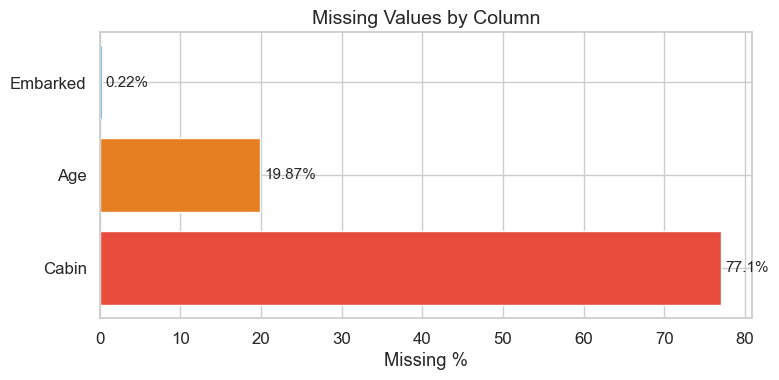

In [11]:
# Visualise missing values
fig, ax = plt.subplots(figsize=(8, 4))
missing_cols = missing[missing['Missing Count'] > 0]

bars = ax.barh(missing_cols.index, missing_cols['Missing %'], color=['#e74c3c', '#e67e22', '#3498db'])
ax.set_xlabel('Missing %')
ax.set_title('Missing Values by Column')

for bar, val in zip(bars, missing_cols['Missing %']):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
            f'{val}%', va='center', fontsize=11)

plt.tight_layout()
plt.show()

In [12]:
# Does Age missingness correlate with survival?
print('Survival rate — Age MISSING vs PRESENT:')
print(df.groupby(df['Age'].isnull())['Survived'].mean().rename({True: 'Age Missing', False: 'Age Present'}))

Survival rate — Age MISSING vs PRESENT:
Age
Age Present    0.406162
Age Missing    0.293785
Name: Survived, dtype: float64


**Missing Value Summary:**
- **Cabin (77.1%)** — Too sparse to use directly. Can be engineered to a binary `has_cabin` flag.
- **Age (19.9%)** — Substantial. Survival rate is slightly different when Age is missing, suggesting this may be **MAR (Missing At Random)** correlated with class/ticket type.
- **Embarked (0.2%)** — Negligible. Can be filled with mode ('S').

---
## 4. Univariate Analysis — Distributions

Examine each variable independently to understand its shape, range, and any outliers.

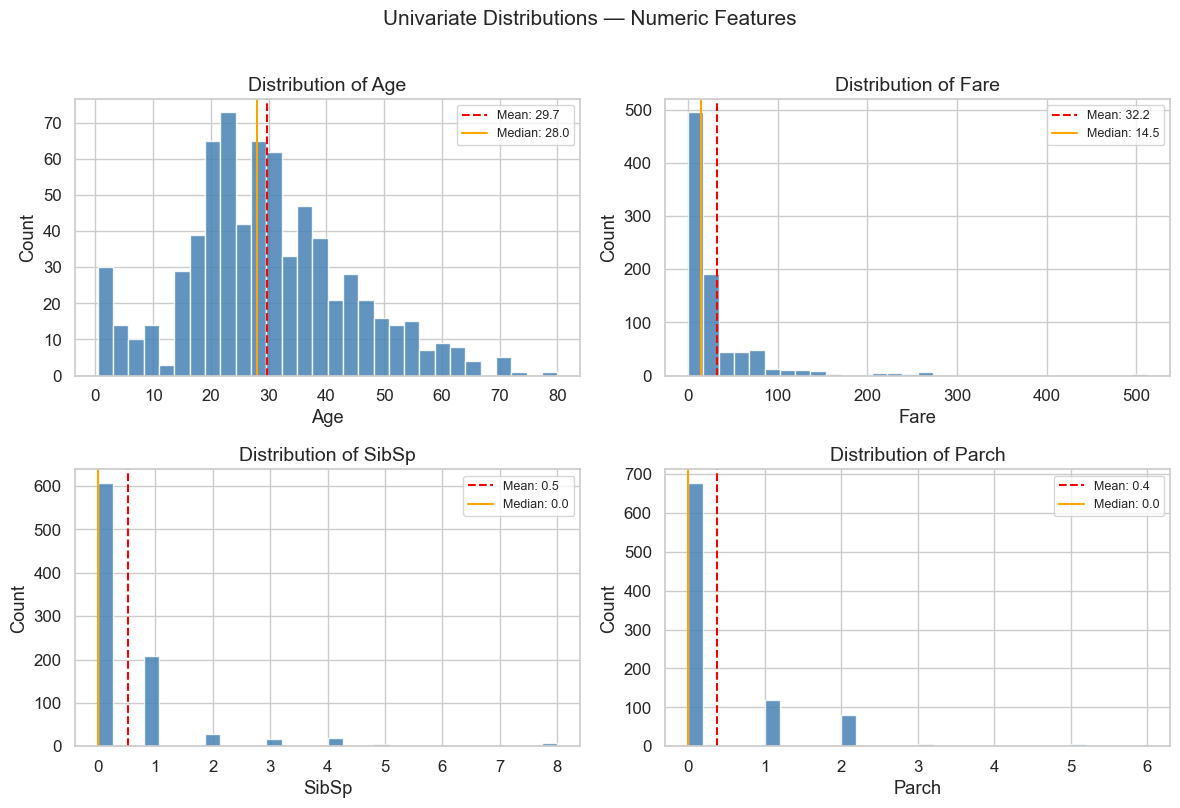

In [13]:
# ── Numeric columns: Age, Fare, SibSp, Parch ──
numeric_cols = ['Age', 'Fare', 'SibSp', 'Parch']

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    axes[i].hist(df[col].dropna(), bins=30, color='steelblue', edgecolor='white', alpha=0.85)
    axes[i].set_title(f'Distribution of {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Count')
    # Add mean and median lines
    axes[i].axvline(df[col].mean(), color='red', linestyle='--', linewidth=1.5, label=f'Mean: {df[col].mean():.1f}')
    axes[i].axvline(df[col].median(), color='orange', linestyle='-', linewidth=1.5, label=f'Median: {df[col].median():.1f}')
    axes[i].legend(fontsize=9)

plt.suptitle('Univariate Distributions — Numeric Features', fontsize=15, y=1.01)
plt.tight_layout()
plt.show()

Fare statistics:
count    891.000000
mean      32.204208
std       49.693429
min        0.000000
25%        7.910400
50%       14.454200
75%       31.000000
max      512.329200
Name: Fare, dtype: float64

Top 5 fares: [np.float64(512.3292), np.float64(512.3292), np.float64(512.3292), np.float64(263.0), np.float64(263.0)]


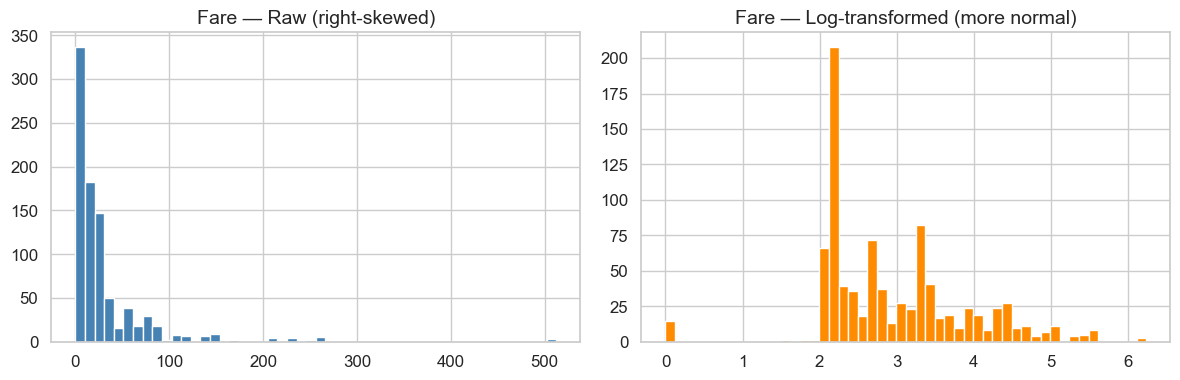

In [14]:
# Fare has extreme outliers — let's check
print('Fare statistics:')
print(df['Fare'].describe())
print(f'\nTop 5 fares: {sorted(df["Fare"].values, reverse=True)[:5]}')

# Log-transformed Fare for better visual
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(df['Fare'], bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('Fare — Raw (right-skewed)')

axes[1].hist(np.log1p(df['Fare']), bins=50, color='darkorange', edgecolor='white')
axes[1].set_title('Fare — Log-transformed (more normal)')

plt.tight_layout()
plt.show()

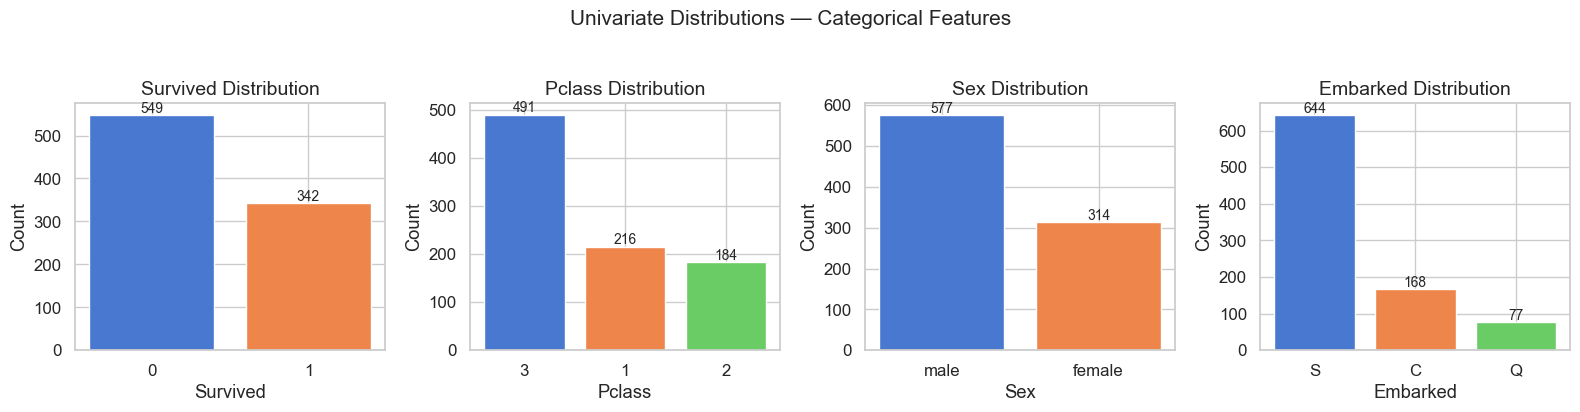

In [15]:
# ── Categorical columns ──
cat_cols = ['Survived', 'Pclass', 'Sex', 'Embarked']

fig, axes = plt.subplots(1, 4, figsize=(16, 4))

for i, col in enumerate(cat_cols):
    vc = df[col].value_counts()
    axes[i].bar(vc.index.astype(str), vc.values, color=sns.color_palette('muted', len(vc)))
    axes[i].set_title(f'{col} Distribution')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Count')
    for j, (idx, val) in enumerate(zip(vc.index.astype(str), vc.values)):
        axes[i].text(j, val + 5, str(val), ha='center', fontsize=10)

plt.suptitle('Univariate Distributions — Categorical Features', fontsize=15, y=1.03)
plt.tight_layout()
plt.show()

**Univariate Observations:**
- **Age**: Roughly normal, peak around 20–30, with a small infant cluster (age < 5).
- **Fare**: Highly right-skewed. A few passengers paid 10× the median fare. Log transformation normalises it.
- **SibSp / Parch**: Most passengers travelled alone (0 siblings/spouses, 0 parents/children).
- **Survival**: Class imbalance — only ~38% survived.
- **Sex**: ~65% male, ~35% female.
- **Pclass**: 55% of passengers were in 3rd class.
- **Embarked**: ~72% boarded at Southampton (S).

---
## 5. Bivariate Analysis — Survival vs Features

Now we ask: **which features are most associated with survival?** This is the core of predictive EDA.

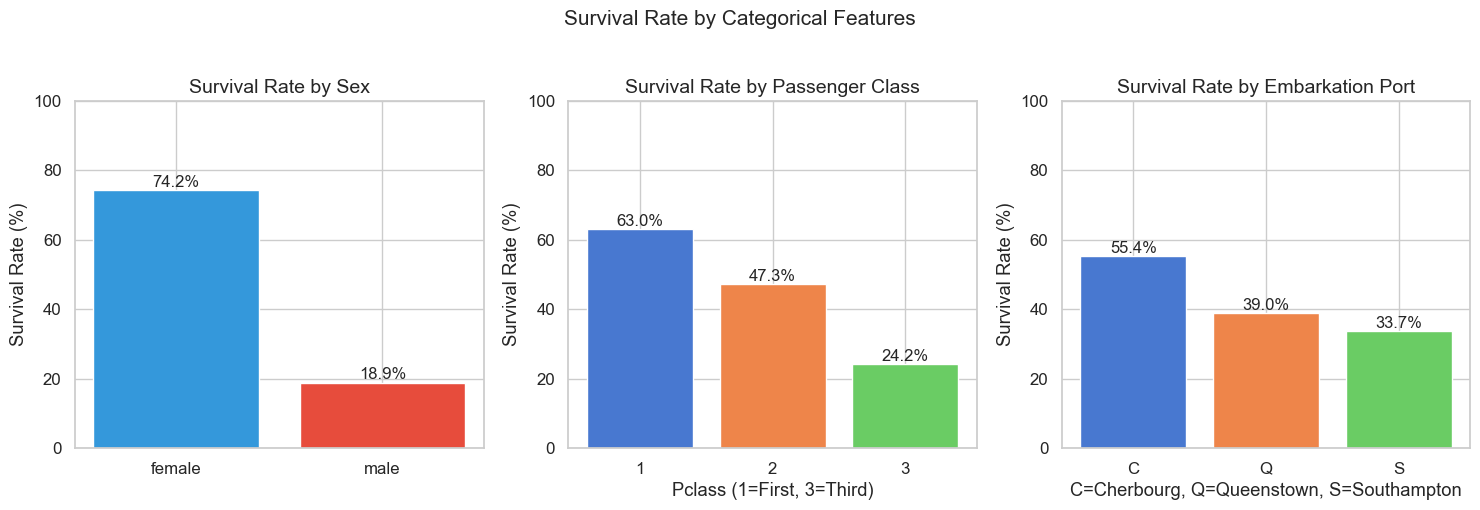

In [16]:
# Survival rate by Sex
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Sex
survival_sex = df.groupby('Sex')['Survived'].mean()
axes[0].bar(survival_sex.index, survival_sex.values * 100,
            color=['#3498db', '#e74c3c'])
axes[0].set_title('Survival Rate by Sex')
axes[0].set_ylabel('Survival Rate (%)')
axes[0].set_ylim(0, 100)
for i, (idx, val) in enumerate(survival_sex.items()):
    axes[0].text(i, val*100 + 1, f'{val*100:.1f}%', ha='center', fontsize=12)

# Pclass
survival_class = df.groupby('Pclass')['Survived'].mean()
axes[1].bar(survival_class.index.astype(str), survival_class.values * 100,
            color=sns.color_palette('muted', 3))
axes[1].set_title('Survival Rate by Passenger Class')
axes[1].set_ylabel('Survival Rate (%)')
axes[1].set_ylim(0, 100)
axes[1].set_xlabel('Pclass (1=First, 3=Third)')
for i, (idx, val) in enumerate(survival_class.items()):
    axes[1].text(i, val*100 + 1, f'{val*100:.1f}%', ha='center', fontsize=12)

# Embarked
survival_emb = df.groupby('Embarked')['Survived'].mean()
axes[2].bar(survival_emb.index, survival_emb.values * 100,
            color=sns.color_palette('muted', 3))
axes[2].set_title('Survival Rate by Embarkation Port')
axes[2].set_ylabel('Survival Rate (%)')
axes[2].set_ylim(0, 100)
axes[2].set_xlabel('C=Cherbourg, Q=Queenstown, S=Southampton')
for i, (idx, val) in enumerate(survival_emb.items()):
    axes[2].text(i, val*100 + 1, f'{val*100:.1f}%', ha='center', fontsize=12)

plt.suptitle('Survival Rate by Categorical Features', fontsize=15, y=1.02)
plt.tight_layout()
plt.show()

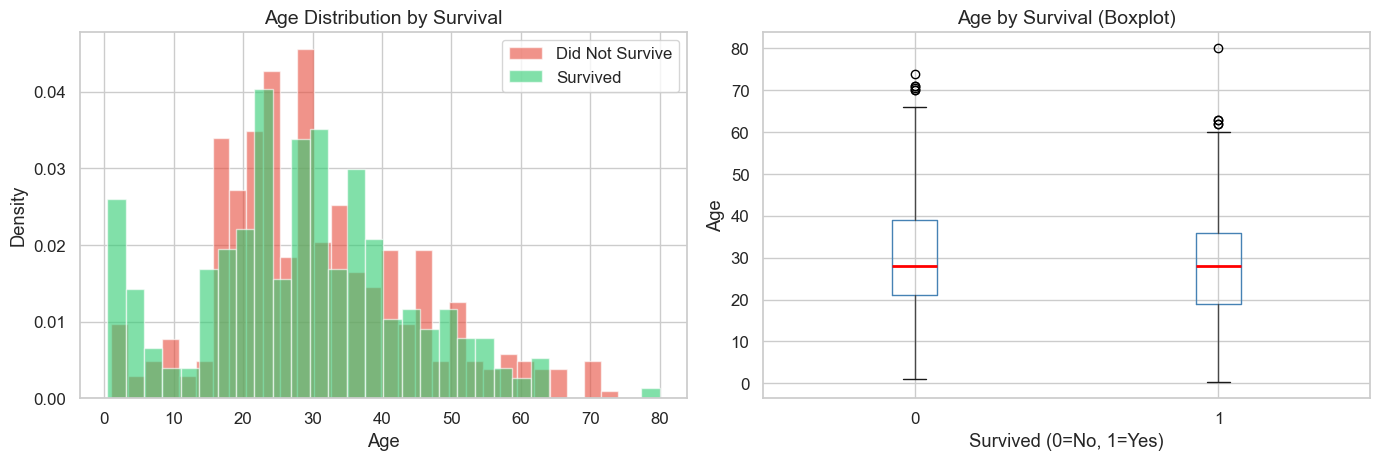

Mean age — Survived: 28.3 | Not Survived: 30.6


In [17]:
# Age distribution by Survival
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# KDE plot
survived = df[df['Survived'] == 1]['Age'].dropna()
not_survived = df[df['Survived'] == 0]['Age'].dropna()

axes[0].hist(not_survived, bins=30, alpha=0.6, color='#e74c3c', label='Did Not Survive', density=True)
axes[0].hist(survived, bins=30, alpha=0.6, color='#2ecc71', label='Survived', density=True)
axes[0].set_title('Age Distribution by Survival')
axes[0].set_xlabel('Age')
axes[0].set_ylabel('Density')
axes[0].legend()

# Boxplot
df.boxplot(column='Age', by='Survived', ax=axes[1],
           boxprops=dict(color='steelblue'),
           medianprops=dict(color='red', linewidth=2))
axes[1].set_title('Age by Survival (Boxplot)')
axes[1].set_xlabel('Survived (0=No, 1=Yes)')
axes[1].set_ylabel('Age')
plt.suptitle('')  # Remove pandas auto-title

plt.tight_layout()
plt.show()

print(f'Mean age — Survived: {survived.mean():.1f} | Not Survived: {not_survived.mean():.1f}')

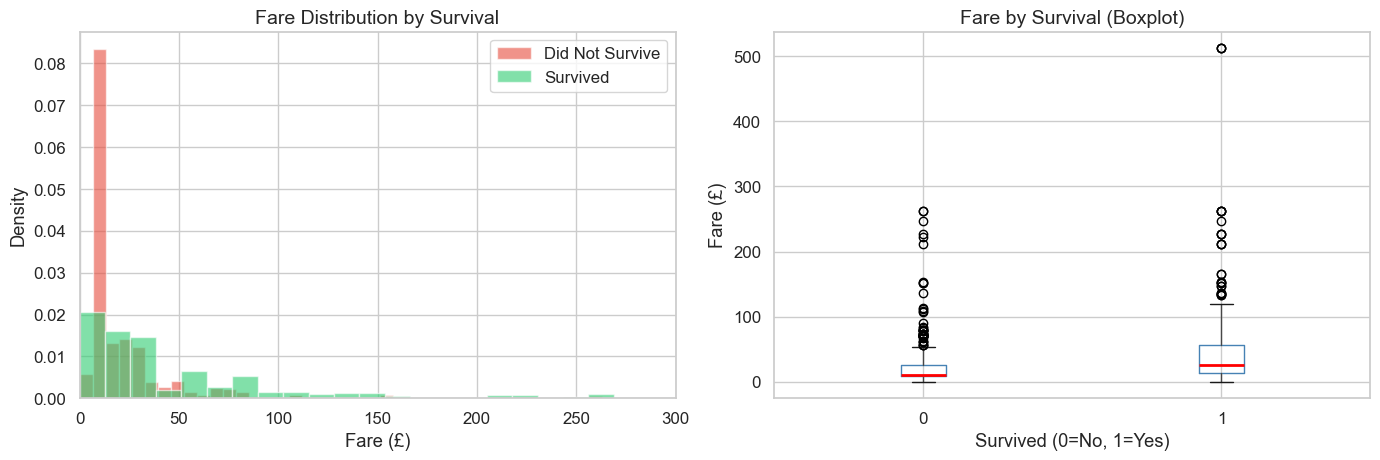

Median fare — Survived: £26.0 | Not Survived: £10.5


In [18]:
# Fare vs Survival
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

survived_fare = df[df['Survived'] == 1]['Fare']
not_survived_fare = df[df['Survived'] == 0]['Fare']

axes[0].hist(not_survived_fare, bins=40, alpha=0.6, color='#e74c3c', label='Did Not Survive', density=True)
axes[0].hist(survived_fare, bins=40, alpha=0.6, color='#2ecc71', label='Survived', density=True)
axes[0].set_title('Fare Distribution by Survival')
axes[0].set_xlabel('Fare (£)')
axes[0].set_ylabel('Density')
axes[0].legend()
axes[0].set_xlim(0, 300)

df.boxplot(column='Fare', by='Survived', ax=axes[1],
           boxprops=dict(color='steelblue'),
           medianprops=dict(color='red', linewidth=2))
axes[1].set_title('Fare by Survival (Boxplot)')
axes[1].set_xlabel('Survived (0=No, 1=Yes)')
axes[1].set_ylabel('Fare (£)')
plt.suptitle('')

plt.tight_layout()
plt.show()

print(f'Median fare — Survived: £{survived_fare.median():.1f} | Not Survived: £{not_survived_fare.median():.1f}')

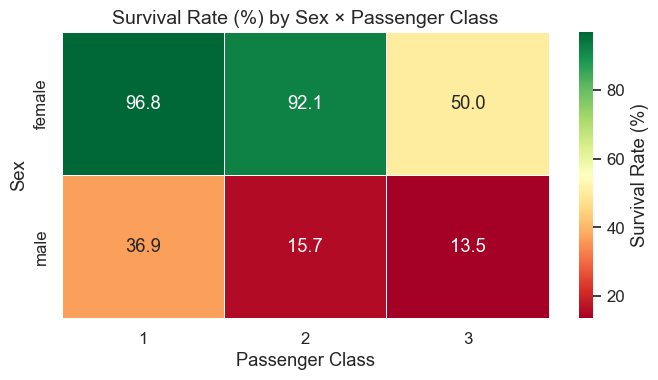

In [19]:
# Interaction: Sex × Pclass → Survival (heatmap)
pivot = df.groupby(['Sex', 'Pclass'])['Survived'].mean().unstack()

fig, ax = plt.subplots(figsize=(7, 4))
sns.heatmap(pivot * 100, annot=True, fmt='.1f', cmap='RdYlGn',
            linewidths=0.5, ax=ax,
            cbar_kws={'label': 'Survival Rate (%)'})
ax.set_title('Survival Rate (%) by Sex × Passenger Class')
ax.set_xlabel('Passenger Class')
ax.set_ylabel('Sex')
plt.tight_layout()
plt.show()

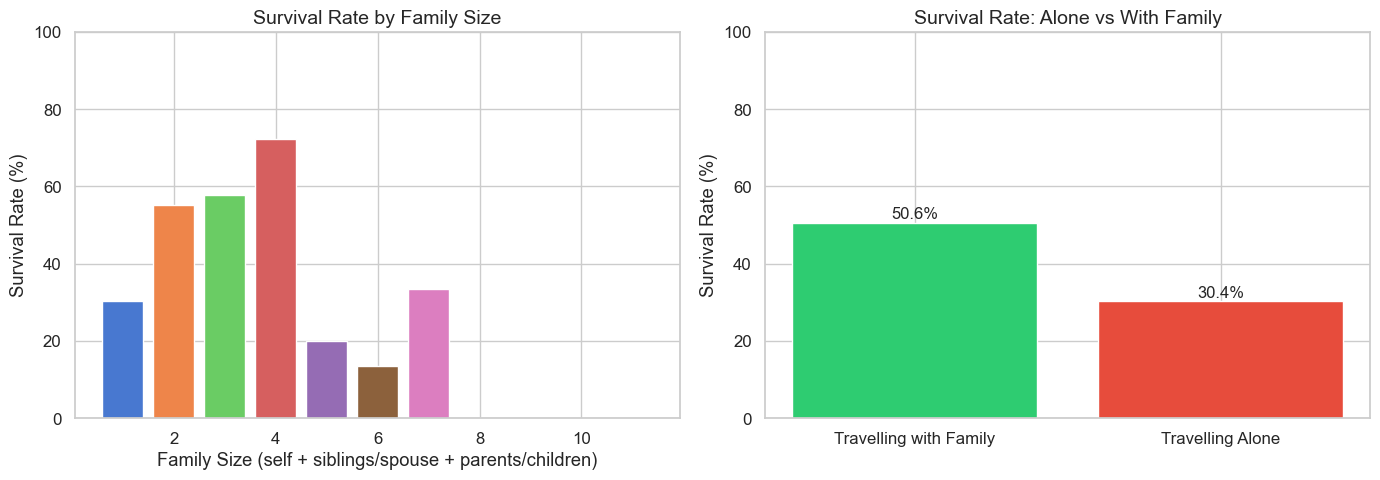

In [20]:
# Family size and survival
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1  # +1 for self
df['IsAlone'] = (df['FamilySize'] == 1).astype(int)

family_survival = df.groupby('FamilySize')['Survived'].mean()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(family_survival.index, family_survival.values * 100,
            color=sns.color_palette('muted', len(family_survival)))
axes[0].set_title('Survival Rate by Family Size')
axes[0].set_xlabel('Family Size (self + siblings/spouse + parents/children)')
axes[0].set_ylabel('Survival Rate (%)')
axes[0].set_ylim(0, 100)

alone_survival = df.groupby('IsAlone')['Survived'].mean()
labels = ['Travelling with Family', 'Travelling Alone']
axes[1].bar(labels, alone_survival.values * 100, color=['#2ecc71', '#e74c3c'])
axes[1].set_title('Survival Rate: Alone vs With Family')
axes[1].set_ylabel('Survival Rate (%)')
axes[1].set_ylim(0, 100)
for i, val in enumerate(alone_survival.values):
    axes[1].text(i, val*100 + 1, f'{val*100:.1f}%', ha='center', fontsize=12)

plt.tight_layout()
plt.show()

**Bivariate Observations:**
- **Sex**: Strongest predictor. Women survived at **74.2%** vs men at **18.9%** — clear evidence of "women and children first."
- **Pclass**: Strong gradient. 1st class: 63%, 2nd class: 47%, 3rd class: 24%.
- **Sex × Pclass interaction**: 1st-class women survived at **97%**. 3rd-class men at only **13.5%**.
- **Age**: Children (age < 10) had higher survival. Middle-aged adults had lower rates.
- **Fare**: Survivors paid significantly higher median fares (correlated with Pclass).
- **Family Size**: Solo travellers had lower survival (30%) vs small families of 2–4 (~55%). Very large families (5+) also had low survival — too many to evacuate together.

---
## 6. Correlation Analysis

Correlation measures linear relationships between numeric variables. Note: correlation ≠ causation.

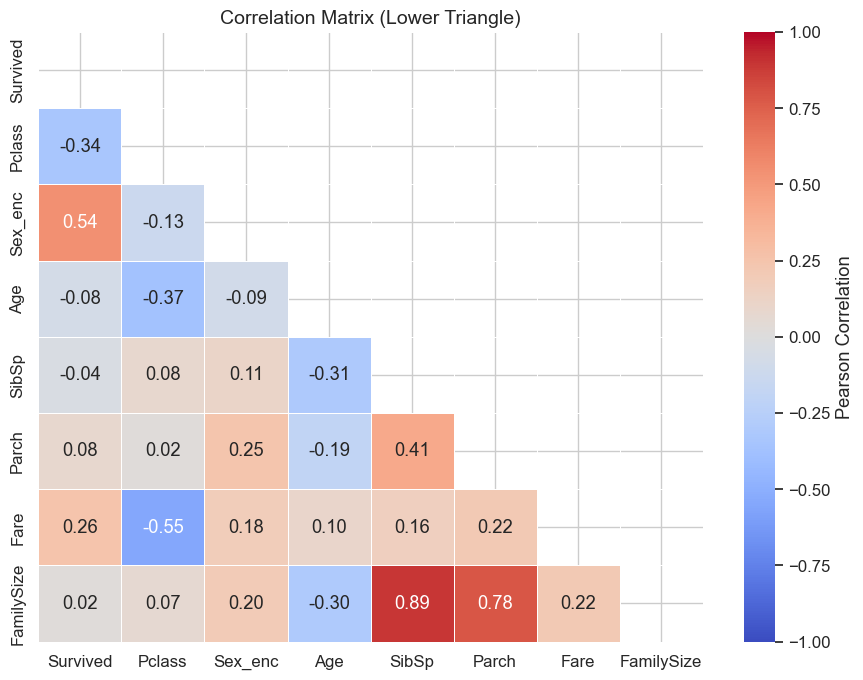


Correlation with Survived (sorted by absolute value):
Sex_enc       0.543351
Pclass        0.338481
Fare          0.257307
Parch         0.081629
Age           0.077221
SibSp         0.035322
FamilySize    0.016639
Name: Survived, dtype: float64


In [21]:
# Encode Sex for correlation (male=0, female=1)
df_corr = df.copy()
df_corr['Sex_enc'] = (df_corr['Sex'] == 'female').astype(int)
df_corr['FamilySize'] = df_corr['SibSp'] + df_corr['Parch'] + 1

corr_cols = ['Survived', 'Pclass', 'Sex_enc', 'Age', 'SibSp', 'Parch', 'Fare', 'FamilySize']
corr_matrix = df_corr[corr_cols].corr()

fig, ax = plt.subplots(figsize=(9, 7))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))  # Upper triangle mask

sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
            cmap='coolwarm', center=0, vmin=-1, vmax=1,
            linewidths=0.5, ax=ax,
            cbar_kws={'label': 'Pearson Correlation'})

ax.set_title('Correlation Matrix (Lower Triangle)', fontsize=14)
plt.tight_layout()
plt.show()

# Correlation with Survived only (sorted)
print('\nCorrelation with Survived (sorted by absolute value):')
print(corr_matrix['Survived'].drop('Survived').abs().sort_values(ascending=False))

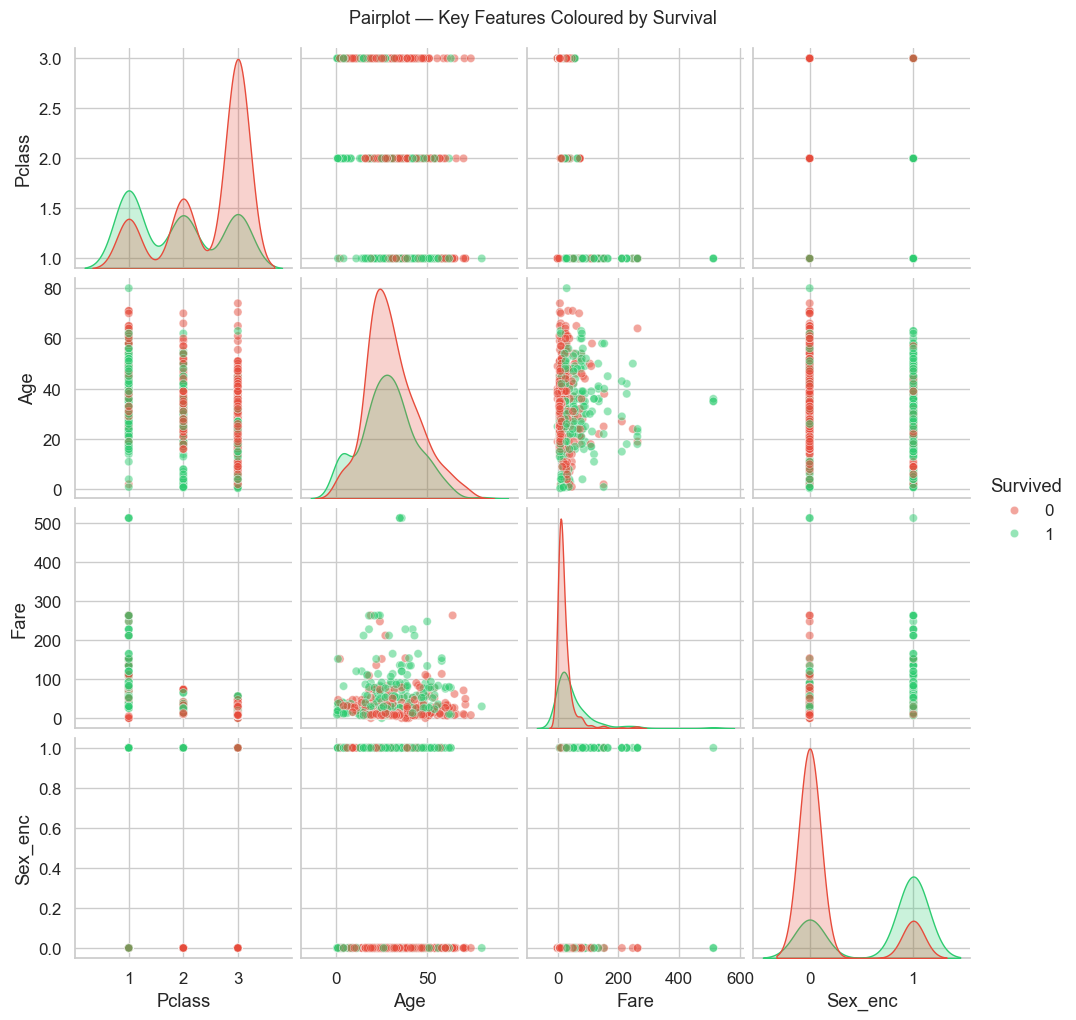

In [22]:
# Pairplot for key variables
pp_cols = ['Survived', 'Pclass', 'Age', 'Fare']
g = sns.pairplot(df_corr[pp_cols + ['Sex_enc']].dropna(),
                 hue='Survived',
                 palette={0: '#e74c3c', 1: '#2ecc71'},
                 plot_kws={'alpha': 0.5},
                 diag_kind='kde')
g.fig.suptitle('Pairplot — Key Features Coloured by Survival', y=1.02, fontsize=13)
plt.show()

**Correlation Observations:**
- `Sex_enc` (being female) has the **highest positive correlation with survival** (r ≈ 0.54)
- `Pclass` has a **strong negative correlation with survival** (r ≈ −0.34) — higher class number = lower class = lower survival
- `Fare` is positively correlated with survival (r ≈ 0.26), and strongly negatively correlated with Pclass (r ≈ −0.55)
- `Age` has a weak negative correlation (r ≈ −0.07)
- `SibSp` and `Parch` are moderately correlated with each other — captured better via `FamilySize`

---
## 7. Feature Engineering Observations

Based on EDA, here are features worth extracting for modelling.

In [23]:
# Extract Title from Name — carries social status info
df['Title'] = df['Name'].str.extract(r' ([A-Za-z]+)\.', expand=False)

print('Value counts for Title:')
print(df['Title'].value_counts())

Value counts for Title:
Title
Mr          517
Miss        182
Mrs         125
Master       40
Dr            7
Rev           6
Col           2
Mlle          2
Major         2
Ms            1
Mme           1
Don           1
Lady          1
Sir           1
Capt          1
Countess      1
Jonkheer      1
Name: count, dtype: int64


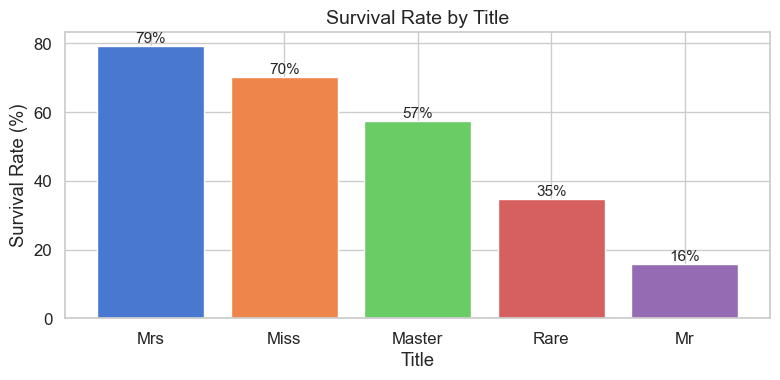

In [24]:
# Simplify titles
title_map = {
    'Mr': 'Mr', 'Miss': 'Miss', 'Mrs': 'Mrs', 'Master': 'Master',
    'Dr': 'Rare', 'Rev': 'Rare', 'Col': 'Rare', 'Major': 'Rare',
    'Mlle': 'Miss', 'Countess': 'Rare', 'Ms': 'Miss', 'Lady': 'Rare',
    'Jonkheer': 'Rare', 'Don': 'Rare', 'Dona': 'Rare', 'Mme': 'Mrs',
    'Capt': 'Rare', 'Sir': 'Rare'
}
df['Title'] = df['Title'].map(title_map)

title_survival = df.groupby('Title')['Survived'].mean().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(title_survival.index, title_survival.values * 100,
       color=sns.color_palette('muted', len(title_survival)))
ax.set_title('Survival Rate by Title')
ax.set_xlabel('Title')
ax.set_ylabel('Survival Rate (%)')
for i, val in enumerate(title_survival.values):
    ax.text(i, val*100 + 1, f'{val*100:.0f}%', ha='center', fontsize=11)
plt.tight_layout()
plt.show()

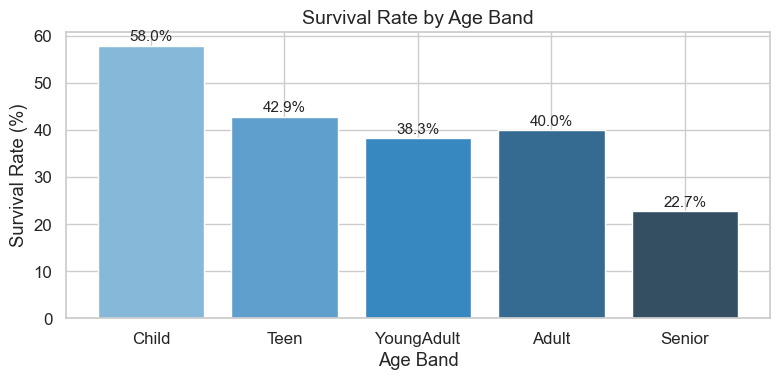

In [25]:
# Age bands
df['AgeBand'] = pd.cut(df['Age'], bins=[0, 12, 18, 35, 60, 100],
                        labels=['Child', 'Teen', 'YoungAdult', 'Adult', 'Senior'])

age_survival = df.groupby('AgeBand', observed=True)['Survived'].mean()

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(age_survival.index.astype(str), age_survival.values * 100,
       color=sns.color_palette('Blues_d', len(age_survival)))
ax.set_title('Survival Rate by Age Band')
ax.set_xlabel('Age Band')
ax.set_ylabel('Survival Rate (%)')
for i, val in enumerate(age_survival.values):
    ax.text(i, val*100 + 1, f'{val*100:.1f}%', ha='center', fontsize=11)
plt.tight_layout()
plt.show()

**Feature Engineering Notes:**
- **Title** extracted from Name is a powerful proxy for gender + social class. 'Mrs' and 'Miss' survive at ~70–79%.
- **Age Bands**: Children (0–12) had ~58% survival — consistent with evacuation priority.
- **FamilySize / IsAlone**: Already engineered above — small families fared better.
- **HasCabin**: Could binary-encode whether a passenger had a cabin record (proxy for wealth).
- **LogFare**: Log-transformed fare reduces the effect of extreme outliers.

---
## 8. Key Insights Summary

A clean, final summary of every significant finding from this EDA.

In [26]:
print('='*65)
print('TITANIC EDA — KEY FINDINGS')
print('='*65)

print(f"""
DATASET
  • 891 passengers, 12 original features
  • Overall survival rate: {df['Survived'].mean()*100:.1f}%

MISSING VALUES
  • Cabin: 77.1% missing → engineer as HasCabin flag
  • Age:   19.9% missing → impute by Title/Pclass group median
  • Embarked: 0.2% missing → fill with mode ('S')

TOP SURVIVAL FACTORS (in order of effect size)
  1. Sex        — Female: 74.2% | Male: 18.9%
  2. Pclass     — 1st: 63% | 2nd: 47% | 3rd: 24%
  3. Fare       — Higher fare → higher survival (correlated with class)
  4. Title      — Mrs: 79% | Miss: 70% | Mr: 16% | Master: 58%
  5. Family     — Small families (2–4) survived better than solo travellers
  6. Age        — Children (0–12) had priority; seniors fared worst

INTERACTIONS
  • 1st-class women: 97% survival → near-perfect evacuation
  • 3rd-class men:   13.5% survival → worst outcome
  • Embarked at Cherbourg: 55% survival (higher proportion of 1st class)

RECOMMENDED FEATURES FOR MODELLING
  Sex, Pclass, Title, FamilySize, IsAlone, AgeBand,
  LogFare, HasCabin, Embarked

NEXT STEPS
  → Handle missing values (Age imputation, Embarked fill)
  → Encode categoricals (LabelEncoder / OneHot)
  → Build baseline: Logistic Regression → Random Forest
  → Evaluate with cross-validation (F1, AUC-ROC)
""")
print('='*65)

TITANIC EDA — KEY FINDINGS

DATASET
  • 891 passengers, 12 original features
  • Overall survival rate: 38.4%

MISSING VALUES
  • Cabin: 77.1% missing → engineer as HasCabin flag
  • Age:   19.9% missing → impute by Title/Pclass group median
  • Embarked: 0.2% missing → fill with mode ('S')

TOP SURVIVAL FACTORS (in order of effect size)
  1. Sex        — Female: 74.2% | Male: 18.9%
  2. Pclass     — 1st: 63% | 2nd: 47% | 3rd: 24%
  3. Fare       — Higher fare → higher survival (correlated with class)
  4. Title      — Mrs: 79% | Miss: 70% | Mr: 16% | Master: 58%
  5. Family     — Small families (2–4) survived better than solo travellers
  6. Age        — Children (0–12) had priority; seniors fared worst

INTERACTIONS
  • 1st-class women: 97% survival → near-perfect evacuation
  • 3rd-class men:   13.5% survival → worst outcome
  • Embarked at Cherbourg: 55% survival (higher proportion of 1st class)

RECOMMENDED FEATURES FOR MODELLING
  Sex, Pclass, Title, FamilySize, IsAlone, AgeBand,

---

## ✅ EDA Complete

This notebook covered the full EDA pipeline:

| Step | What was done |
|------|---------------|
| Data Loading | Loaded from public URL, verified shape/dtypes |
| Missing Values | Quantified, visualised, checked for pattern |
| Univariate | Distributions for numeric + categorical features |
| Bivariate | Survival rates by Sex, Pclass, Age, Fare, Family |
| Interactions | Sex × Pclass heatmap, Title extraction |
| Correlations | Full Pearson matrix + pairplot |
| Engineering | FamilySize, Title, AgeBand, LogFare ideas |
| Insights | Ranked factors, interaction effects, next steps |

**Strongest predictor:** Sex (female). **Second strongest:** Passenger class.